# How To Use Imagix3D
Imagix3D is an implementation of a variational autoencoder for 3D image data (volumes).  
This tutorial follows the structure of `Getting Started - Vanillix`, and repeats many of the parts therein which cover the general functionaliy of the **AUTOENCODIX** framework. The aim is to provide a tutorial for Imagix3D that simultaneously functions as
- a general demonstration of basic **AUTOENCODIX** functionalities
- a specific tutorial about the 3D image pipeline workflow
- an end-to-end test for Imagix3D that covers all its functionalities


## What You'll Learn

You’ll learn how to:

1. **Initialize** the pipeline and run it. <br><br>
2. Understand the Imagix specific **pipeline steps**. <br><br>
3. Access the Imagix specific **results** (mus, sigma, kl/mmd losses). <br><br>
4. **Visualize** outputs effectively. <br><br>
5. Apply **custom parameters**. or Architecture <br><br>
6. **Save, load, and reuse** a trained pipeline. <br><br>


**Setting the Correct Path**

In [1]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")

Changed to: C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package


## 1) Initialize the Imagix3D Pipeline
`Imagix3D` is a VAE implementation for 3D image data. Other data modalities are not allowed for `Imagix3D` (including 2D image data).  
This tutorial will be restricted to 3D human medical imaging data. However, the pipeline also works for other 3D data, provided that they come in a data type which is allwed (see down below). To run the pipeline we need to prepare two things:  

1. A directory with image files. The following extensions are allowed: `".nii", ".nii.gz"` (for the time being - this might change in the future).<br>
2. An annotation file with metadata, where we map `sample_ids` to image paths. For this, we need to provide the name of the column where the image path information is stored. This is done via the `img_path_col` config parameter.<br>
3. A configuration object<br>

### ❗❗Requirements ❗❗
We don't import the data for this Tutorial. This means you have to get sample data from somewhere else. One option is to download data from https://openneuro.org/datasets/. Once you have the data, you should:
- create the directories `data` and `data/volumes`
- place your NIfTI images (`.nii or .nii.gz`) in `data/volumes`
- create an ``annotations.csv` file in `data`, which contains at least one column with sample ids and one column with file names
- see path `IMGROOT` and `IMGMAPPING` in the cell below.
- 
#### 1.1 📊 The Dataset
For the purpose of this tutorial, any structural or functional medical imaging dataset can be used. We recommend to employ sample data from human brain imaging (MRI, CT etc.) as they are most suited for the visualization steps further down the pipeline.

#### 1.2 ⚙️ Configuration Object
We use the default parameters in `Imagix3DConfig`.  
Additionally, we define a `DataCase`, which tells the pipeline what kind of data to expect.  
In this case: `IMG`.  


**A Look Inside the Annotation File**:


In [2]:
import os
import pandas as pd
import autoencodix as acx
from autoencodix.configs.imagix3d_config import Imagix3DConfig
from autoencodix.configs.default_config import (
    DataConfig,
    DataCase,
    DataInfo
)

VOLROOT = os.path.join("src/autoencodix/data/volumes/sample_data/")
VOLANNO= os.path.join("src/autoencodix/data/volumes/annotation.csv")
anno_df = pd.read_csv(VOLANNO, sep=",", index_col=0)
anno_df.head()

,filepath,group
subject_id,,
subject_01,sub-01_T1.nii,YA
subject_02,sub-02_T1.nii,YA
subject_03,sub-03_T1.nii,YA
subject_04,sub-04_T1.nii,YA
subject_05,sub-05_T1.nii,YA


**Define Config**

In [3]:
volconfig = Imagix3DConfig(
    data_case=DataCase.IMG_TO_IMG,
    img_path_col="filepath",
    spatial_shape_policy="crop_or_pad_to_shape",
    target_shape_3d=(224,224,192),
    checkpoint_interval=10,
    epochs=250,
    reconstruction_loss="mse",
    beta=0.005,
    scaling="MINMAX",
    anneal_function="logistic-late",
    data_config=DataConfig(
        data_info={
            "IMG": DataInfo(
                file_path=VOLROOT,
                scaling="MINMAX",
                data_type="IMG",
            ),
            "ANNO": DataInfo(
                file_path=VOLANNO,
                data_type="ANNOTATION",
            ),
        },
    ),
)

imagix3d = acx.Imagix3D(config=volconfig)

## 2) Understand Imagix3D Pipeline Steps

Next, we explain the four main steps of our pipeline:

1. Preprocess  
2. Fit  
3. Predict  
4. Visualize  

We can run all steps together with the `run` method.


### 2.1) Preprocess

If you're familiar with `AUTOENCODIX 1.0`, this is similar to `make data` in the old framework.  
In case you don’t want any preprocessing, you can set `skip_preprocessing=True` in the config object.  
**ATTENTION:** This could lead to `RuntimeErrors` if you violate assumptions like NaN-free data, which we normally handle during preprocessing.  
See Tutorial [1] for details on data requirements and assumptions.  


#### 🧼 Data Cleaning

This step acts as a safety net to avoid runtime errors later in the pipeline. Here, we simply drop columns with NaN values.  
Ideally, you’ve already cleaned the data before putting it into our pipeline if you want more sophisticated handling of NaNs.  
**Note:** For metadata, we allow NaNs as long as they’re not specified in the config as relevant columns (see [2]).  


#### ✂️ Splitting

We designed the preprocessing pipeline to avoid data leakage, so almost all preprocessing transformations are applied **after** splitting the data.  
The only exception is filtering cells and log-transforming single-cell data (if not already done by you).  
The default behavior is to split your input data into three splits: train, validation, and test. You can define the ratio via the config (see [2]) or, for some pipelines, provide a custom split (see [1]).  
Additionally, you can always pass unseen data to the `predict` step of the pipeline.  


#### 🗂️ Filtering

We filter the columns of the train set and apply the learned filtering to the validation and test sets. The filtering method and the number of features to keep can be defined in the config.  

The filtering method can be set per data modality, but we recommend keeping it consistent.  
If you work with multiple data modalities and provide a number for `k_filter` (e.g., 1000), this will be the total number of features across all data modalities. For example, you may have 500 features for modality A and 500 for modality B.  

We provide the following options for filtering:

- `VAR` – Select features with the highest variance  
- `MAD` – Select features with the highest median absolute deviation  
- `CORR` – Select features based on correlation  
- `VARCORR` – Combination of variance and correlation  
- `NOFILT` – No filtering applied  
- `NONZEROVAR` – Select features with non-zero variance  


#### 📏 Scaling

After the filtering step, we scale the data. We fit the scaler on the train set and apply the learned transformations to the validation and test sets.  

Different scaling methods can be applied per data modality, but we strongly recommend setting this globally via the `scaling` parameter. The default is `StandardScaler`.  

We provide the following options for scaling:  
- `STANDARD` – Standard scaling (mean = 0, variance = 1)  
- `MINMAX` – Min–max scaling to range [0, 1]  
- `ROBUST` – Robust scaling using the median and interquartile range  
- `MAXABS` – Scaling by the maximum absolute value  
- `NONE` – No scaling applied  


#### 🐍 Transforming to PyTorch Dataset

In the last step, we transform the data into a custom PyTorch `Dataset` class.  
For the Vanillix pipeline, we concatenate the different data modalities and store them in the `data` attribute of the `Dataset` class.  
Now the data is ready to serve as input for our PyTorch models.  


[1] Tutorials/DeepDives/InputDataTutorials.ipynb <br>
[2] Tutorials/DeepDives/ConfigTutorial.ipynb <br>


#### 🖥️ In Code

All preprocessing steps run with one command in the pipeline:

In [4]:
# This method call does not return anything; the step updates internal attributes:
# It sets the private _datasets attribute.
# It populates the results.datasets attribute with the preprocessed and transformed PyTorch datasets (one for each split).
imagix3d.preprocess()

Successfully loaded 20 images for IMG
calling normalize image in _process_ing_to_img_case
anno key: IMG
Converting 14 images to torch.float32 tensors...
Converting 4 images to torch.float32 tensors...
Converting 2 images to torch.float32 tensors...


Preprocessing sanity check:

In [5]:
assert imagix3d.result.datasets is not None
assert imagix3d.result.datasets.train is not None
assert imagix3d.result.datasets.test is not None
print(imagix3d.result.datasets.train.get_input_dim())

torch.Size([1, 192, 224, 224])


### 2.2) The Fit Step

The fit step trains the autoencoder architecture and captures an extensive set of training dynamics.  
The training and model itself are highly customizable (`n_layers`, `latent_dim`, `epochs`, `learning_rate`, etc.). Refer to [Section 5](#5-customize) or Tutorial [4] for more details.  
During training, we capture losses, latent spaces, and reconstructions for each checkpoint epoch and store them in our results object.

[2] Tutorials/DeepDives/ConfigTutorial.ipynb <br>

In [6]:
# Calls the self.Trainer class to initialize and train the model.
# Populates the self._model attribute with the trained model.
# Populates the self.results attribute with training results (model, losses, etc.).
imagix3d.fit()

Epoch 1 - Train Loss: 4167177.7143
Sub-losses: recon_loss: 4167177.7143, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 385419.4062
Sub-losses: recon_loss: 385419.4062, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 3007877.1429
Sub-losses: recon_loss: 3007877.1429, var_loss: 0.0001, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 385508.4688
Sub-losses: recon_loss: 385508.4688, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Train Loss: 1648366.0000
Sub-losses: recon_loss: 1648365.8571, var_loss: 0.0966, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Valid Loss: 385203.9375
Sub-losses: recon_loss: 385203.9375, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 4 - Train Loss: 1361095.7143
Sub-losses: recon_loss: 1361095.7143, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.000

Fitting sanity check:

In [7]:
assert imagix3d.result.model is not None
assert len(imagix3d.result.losses._data) > 0

### 2.3) The Predict Step

In this step, we use the trained model to run a forward pass on our test dataset.  
This step can also take a `data` argument, allowing you to run predictions on held-out data other than the test split.  
If you provide new data, preprocessing will be applied automatically depending on the data format — see [1] for details.

[1] Tutorials/DeepDives/InputDataTutorials.ipynb

In [8]:
# If no data is passed, this uses the test split from preprocessing.
# Otherwise, uses the provided data and preprocesses it.
# Updates the self.results attribute with predictions (latent space, reconstructions, etc.).
# Returns a results object.
result = imagix3d.predict()

Processed 4 / 4 samples

Prediction sanity check:

In [9]:
assert imagix3d.result.reconstructions.get(split="test", epoch=-1) is not None
assert imagix3d.result.adata_latent is not None

print("train len:", len(imagix3d.result.datasets.train))
print("valid len:", len(imagix3d.result.datasets.valid))
print("test len :", len(imagix3d.result.datasets.test))

print("\nLatent shape:", imagix3d.result.adata_latent.shape)

train len: 14
valid len: 2
test len : 4

Latent shape: (4, 16)


### 2.4) The Visualize Step

This step takes the training results and creates visualizations,  
for example, plots of the loss curve or the latent spaces.  
The plots are stored internally and can be displayed with the `show_result` method.  
See [Section Visualize](#4-visualize) for more details on working with the generated plots.

In [10]:
imagix3d.visualize()

### 2.5) The Run Step

This step combines all the previous steps and returns a results object.  
Furthermore, you can pass a `data` argument, which will then be used in the predict step instead of the test split.

In [11]:
imagix3d = acx.Imagix3D(config=volconfig)
result = imagix3d.run()
backup_dataset = result.datasets

Successfully loaded 20 images for IMG
calling normalize image in _process_ing_to_img_case
anno key: IMG
Converting 14 images to torch.float32 tensors...
Converting 4 images to torch.float32 tensors...
Converting 2 images to torch.float32 tensors...
Epoch 1 - Train Loss: 3409393.7143
Sub-losses: recon_loss: 3409393.7143, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 383887.1250
Sub-losses: recon_loss: 383887.1250, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 2140211.4286
Sub-losses: recon_loss: 2140211.2857, var_loss: 0.0869, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 383235.0938
Sub-losses: recon_loss: 383235.0938, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Train Loss: 1659488.8571
Sub-losses: recon_loss: 1659488.8571, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Valid Loss: 381294.8750
S

### 2.6) Extra: The Evaluate Step

This step is not included when you call `.run()`. Here, we use the `latent space` and compare it to other dimensionality reduction techniques like PCA, UMAP, or a random baseline.  
In the basic case, you can specify a column in your annotation data to use for a machine learning task, e.g., training a classifier on disease state or cancer type. We then use the representations (latent space, UMAP, etc.) to train this classifier/regressor.  
You have many options to customize this step for your needs, such as passing a scikit-learn model and defining evaluation metrics. Please refer to [3] for a complete guide.

[3] Tutorials/DeepDives/EvaluateTutorial.ipynb

In [12]:
# In our annotation file, we have a column called "group"
# that refers to the age group of our subjects.
imagix3d.evaluate(params=["group"])  

Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: group


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VolumeVAEArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._image_dataset.ImageDataset object at 0x000002C9821537D0>, valid=<autoencodix.data._image_dataset.ImageDataset object at 0x000002C9826BCB10>, test=<autoencodix.data._image_dataset.ImageDataset object at 0x000002C9836A88D0>)
new_datasets: DatasetContainer(train=None, valid=None, test=None)
adata_latent: AnnData object with n_obs × n_vars = 4 × 16
    uns: 'var_names'
final_reconst

Showing plot for ML algorithm: LogisticRegression


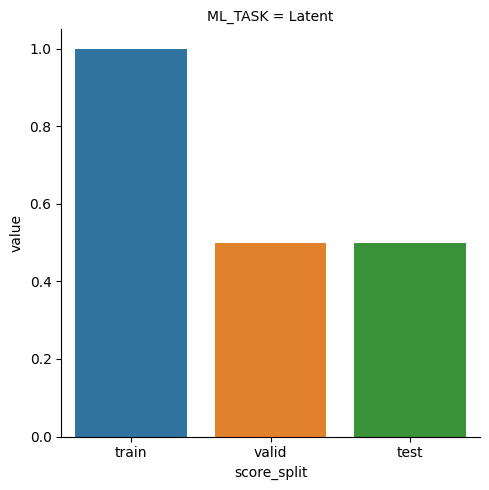

In [13]:
# Next, we can visualize the evaluation output with:
import matplotlib.pyplot as plt
plt.close("all")
imagix3d.visualizer.show_evaluation(
    param="group",
    metric="roc_auc_ovo"
)

## 3) Inspect Results

Each step in the pipeline writes its results to the results object of the Vanillix instance.  
In this section, we explore how to access and make sense of the results.  
The attributes of the results object are instances of a `TrainingDynamics` class.  
This class provides a standardized interface for accessing results from different splits and epochs.

##### TrainingDynamics Object in Results

The `TrainingDynamics` object has the following form:  
`<epoch><split><data>`  

For example, to access the train loss for the 5th epoch, you would use:  
```python
result.loss.get(epoch=5, split="train")
```

##### Special Handling

* If an invalid split is provided, a `KeyError` is raised
* Negative epoch indices work like Python list indexing (-1 is the last epoch)
* If an epoch doesn't exist, an empty array or dictionary is returned


### 3.1) Access Imagix Specific Results
The `result` object follows our standard interface. Refer to [1] for more details.  
We don't have any `Imagix3D` specific results, but you can directly visualize the reconstructions as images, as shown in the code below:

---
For more details on how to work with TrainingDynamics and the Result object, refer to [1] <br>
[1] Tutorials/DeepDives/PipelineOutputTutorial.ipynb


In [14]:
from IPython.display import display

# Get the reconstructions of the test split
rec_test = result.reconstructions.get(split="test")

# Get sample_ids for this latent space
sample_ids = result.sample_ids.get(split="test")

# A utility wrapper to get the latent space as a DataFrame
display(result.get_latent_df(epoch=-1, split="test"))
display(result.mus.get(split="test", epoch=-1))
display(result.sigmas.get(split="test", epoch=-1))
display(result.sub_losses.get(key="var_loss"))

,LatDim_0,LatDim_1,LatDim_2,LatDim_3,LatDim_4,LatDim_5,LatDim_6,LatDim_7,LatDim_8,LatDim_9,LatDim_10,LatDim_11,LatDim_12,LatDim_13,LatDim_14,LatDim_15
subject_05,0.120927,0.495104,1.665897,-1.377053,2.479164,19098.406250,-1.570617,-0.748541,-16969.679688,1.254326,-1.160252,16818.292969,16354.547852,24049.412109,2.242157,0.339540
subject_10,-0.447065,-1.851533,1.085397,0.625735,-0.434569,-40868.332031,1.107615,-2.086428,-14784.701172,-0.277754,-1.378917,1323.790161,-11540.462891,15583.963867,-0.701318,-1.006430
subject_12,1.723647,1.234854,1.091874,0.612618,0.751163,10854.082031,0.538452,1.958832,-29200.687500,-1.400509,0.519603,21593.128906,10795.682617,-28844.824219,1.785362,1.417735
subject_13,0.739320,0.165138,0.502021,1.303781,1.180836,5751.793945,1.497590,0.799927,24001.132812,-0.472238,-0.073707,16949.710938,-35837.492188,16107.550781,62.169903,-0.058712


array([[  0.     ,   0.     ,   0.     ,   0.     ,   0.     , 485.74045,
          0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
          0.     ,   0.     ,   0.     ,   0.     ],
       [  0.     ,   0.     ,   0.     ,   0.     ,   0.     , 843.66705,
          0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
          0.     ,   0.     ,   0.     ,   0.     ],
       [  0.     ,   0.     ,   0.     ,   0.     ,   0.     , 697.5416 ,
          0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
          0.     ,   0.     ,   0.     ,   0.     ],
       [  0.     ,   0.     ,   0.     ,   0.     ,   0.     , 549.8207 ,
          0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
          0.     ,   0.     ,  60.42377,   0.     ]], dtype=float32)

array([[ 0.1,  0.1,  0.1,  0.1,  0.1, 20. ,  0.1,  0.1, 20. ,  0.1,  0.1,
        20. , 20. , 20. ,  0.1,  0.1],
       [ 0.1,  0.1,  0.1,  0.1,  0.1, 20. ,  0.1,  0.1, 20. ,  0.1,  0.1,
        20. , 20. , 20. ,  0.1,  0.1],
       [ 0.1,  0.1,  0.1,  0.1,  0.1, 20. ,  0.1,  0.1, 20. ,  0.1,  0.1,
        20. , 20. , 20. ,  0.1,  0.1],
       [ 0.1,  0.1,  0.1,  0.1,  0.1, 20. ,  0.1,  0.1, 20. ,  0.1,  0.1,
        20. , 20. , 20. ,  0.1,  0.1]], dtype=float32)

TrainingDynamics()

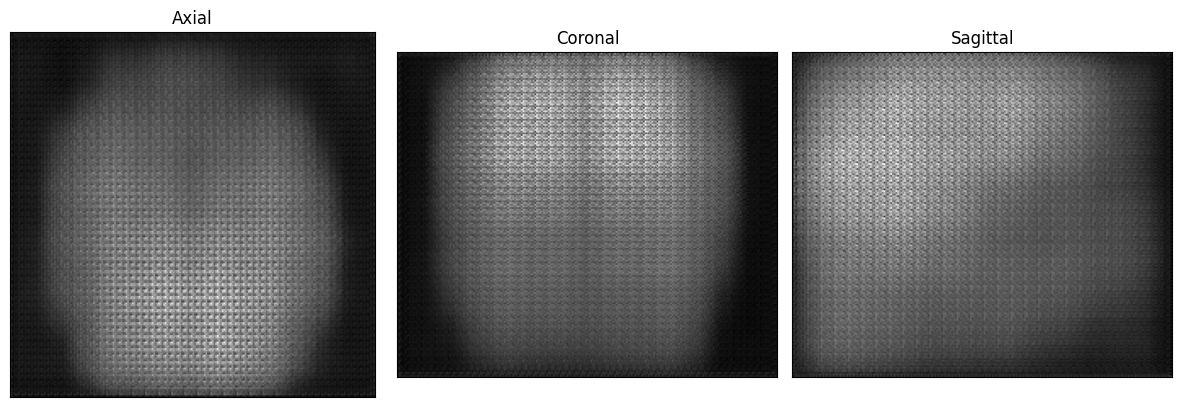

In [15]:
# Display reconstruction
sample_vol = result.reconstructions.get(split="test", epoch=-1)
sample_vol = sample_vol[0, 0, :, :, :]

d_mid, h_mid, w_mid = [s // 2 for s in sample_vol.shape]

axial = sample_vol[d_mid, :, :]
coronal = sample_vol[:, h_mid, :]
sagittal = sample_vol[:, :, w_mid]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial")
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal")
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

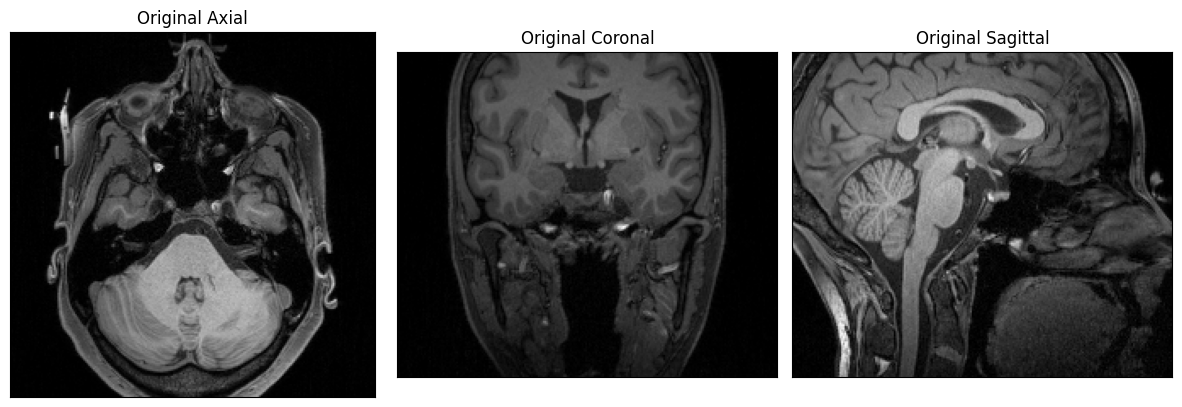

In [16]:
# Display original
sample_orig = imagix3d.result.datasets.test.raw_data[0].img
sample_orig = sample_orig[0, :, :, :] 

d_mid, h_mid, w_mid = [s // 2 for s in sample_orig.shape]

axial = sample_orig[d_mid, :, :]
coronal = sample_orig[:, h_mid, :]
sagittal = sample_orig[:, :, w_mid]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Original Axial")
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Original Coronal")
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Original Sagittal")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 4) Visualize Imagix3D Results
Since the results of `Imagix` are visually interpretable, we add an additional visualization:  
We show a grid of original images and reconstructed images with label information. See the code below for how to obtain this visualization.


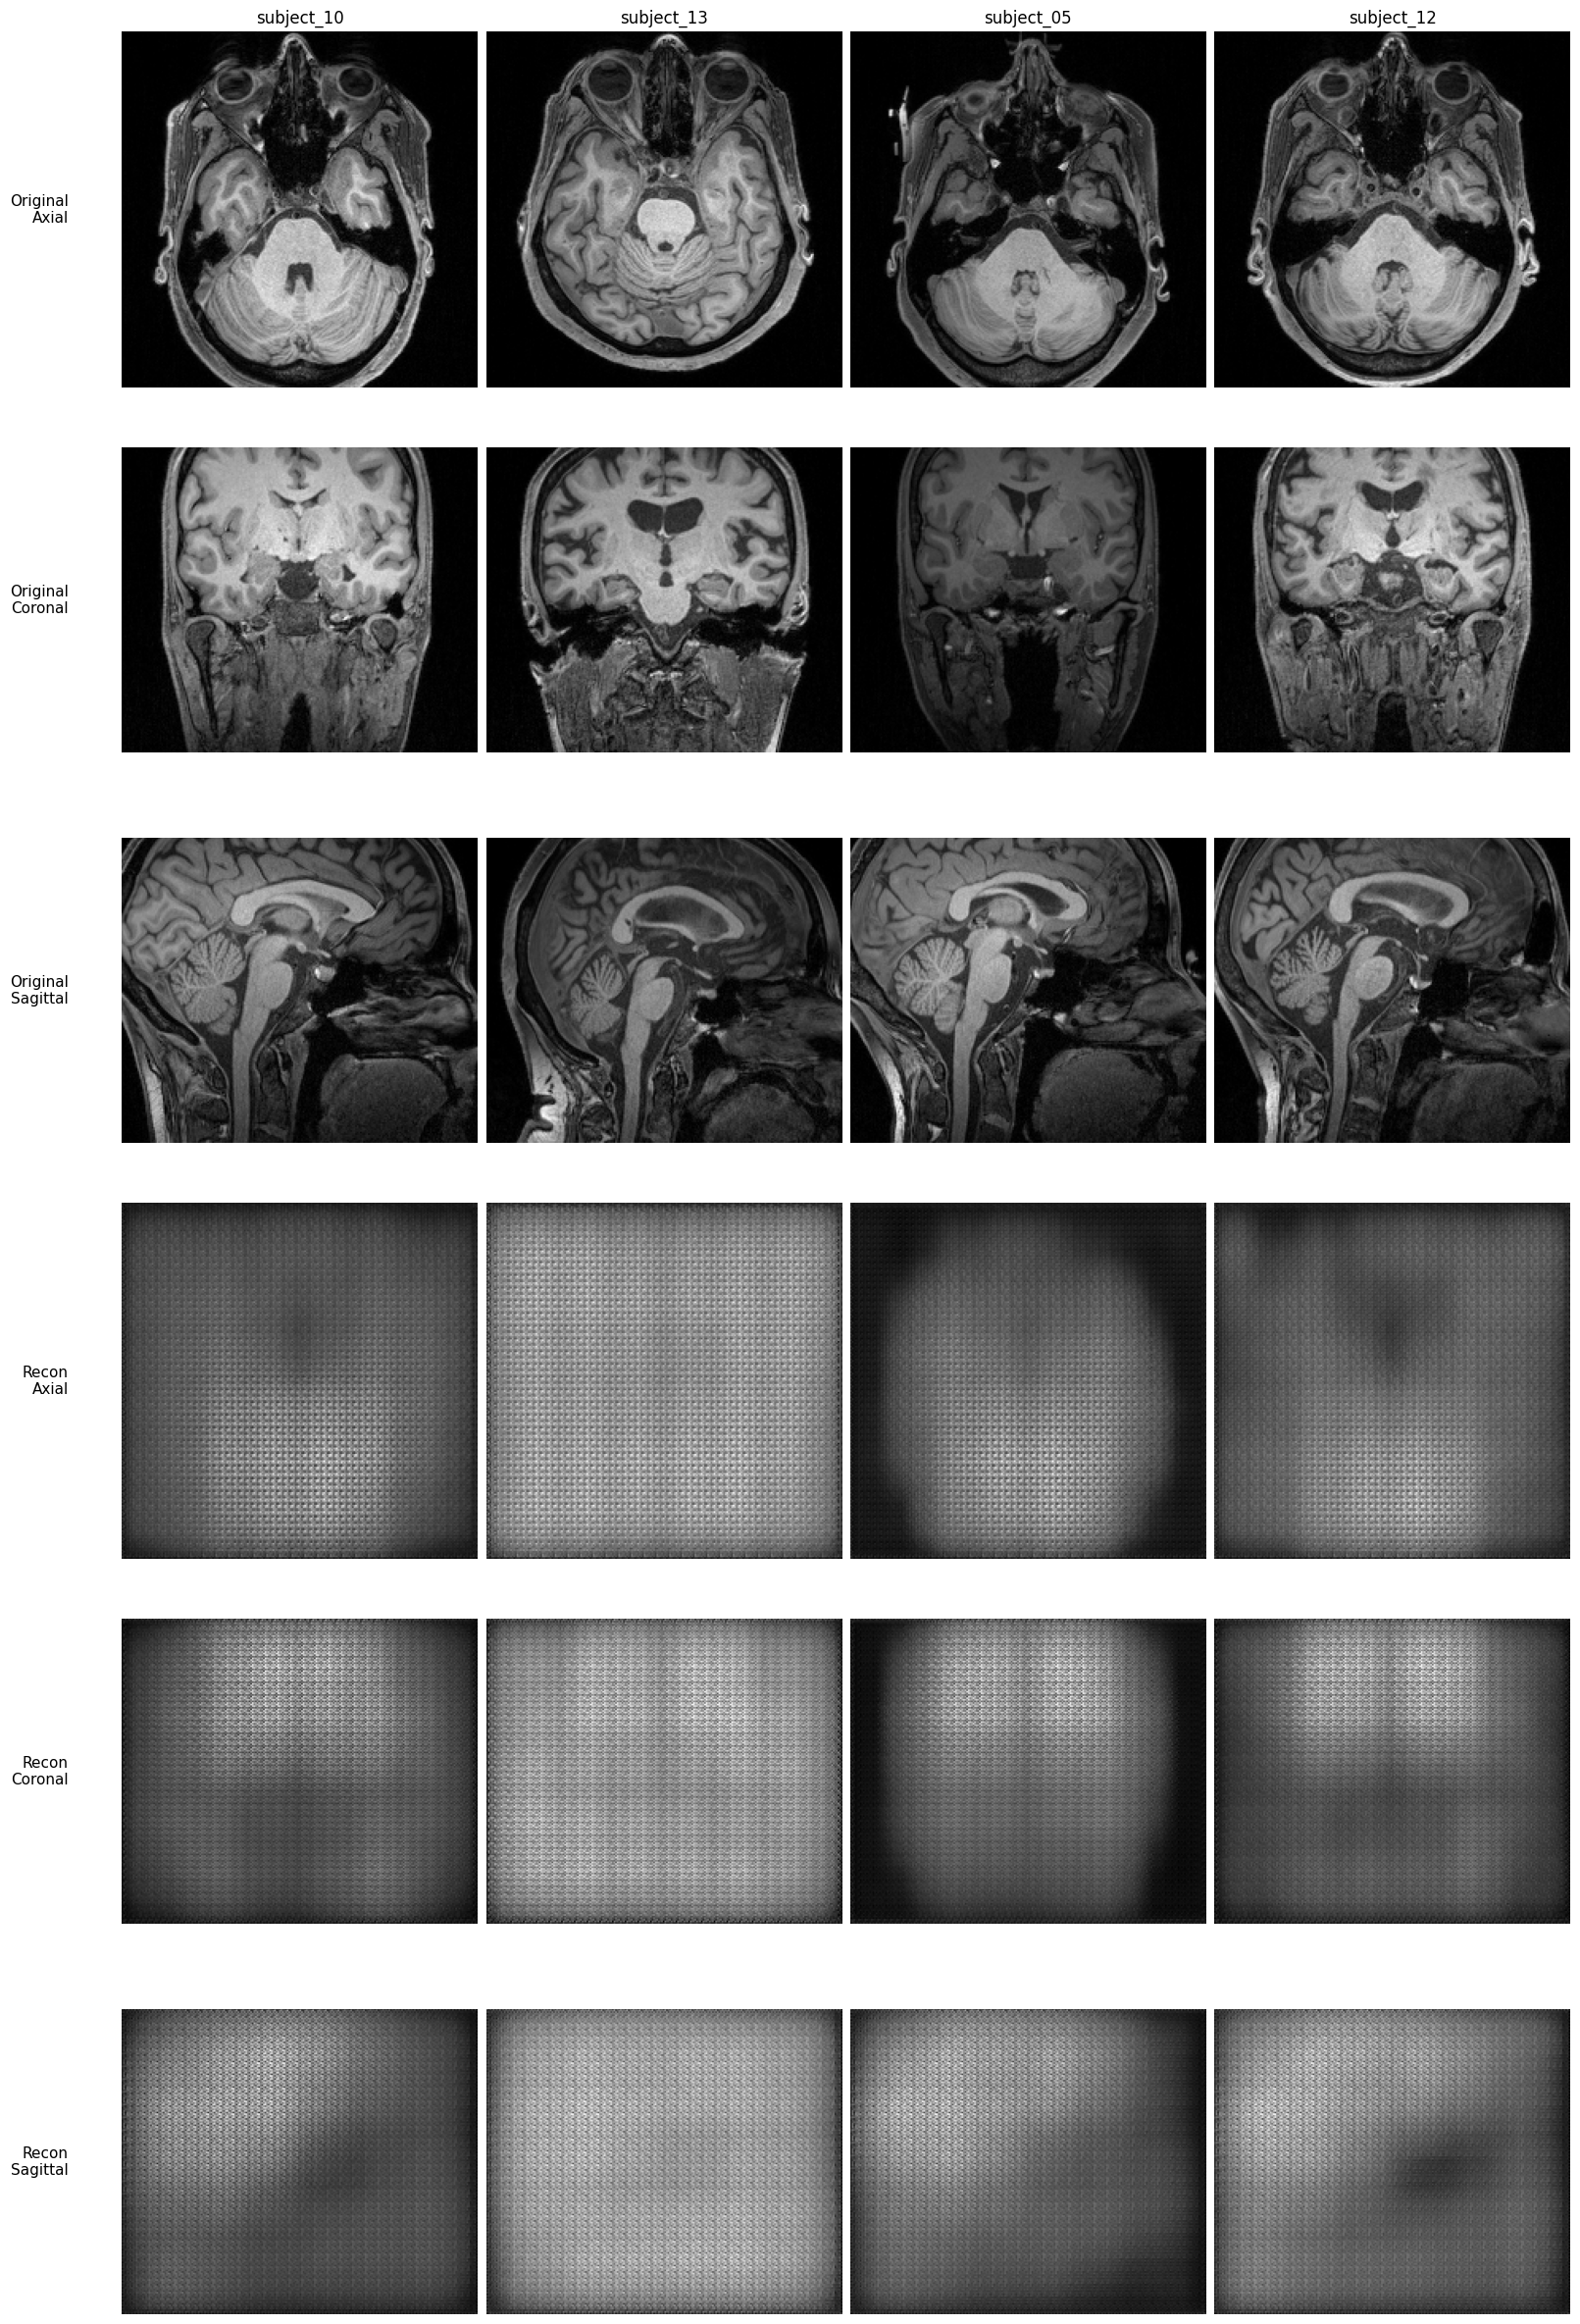

In [17]:
imagix3d.visualizer.show_image_recon_grid(result=imagix3d.result, n_samples=4)

**Standard Visualizations**  
You can call the `show_result` method to display the actual plots. By passing the keyword argument `params` and providing a list of columns from the annotation data, you get visualizations based on these columns. In this example, we use the `group` parameter.  
Refer to [5] for more details on how to work with plots.
 
---
[5] Tutorials/DeepDives/VisualizeTutorial.ipynb

Creating plots ...


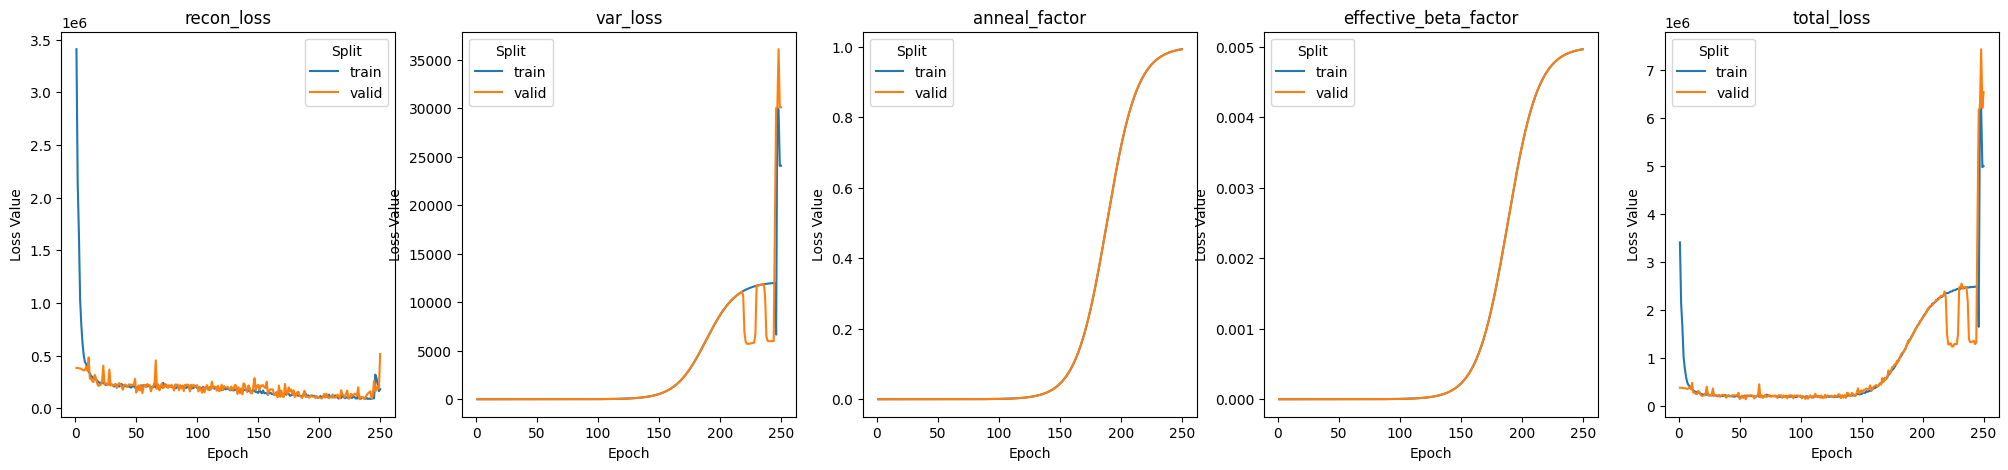

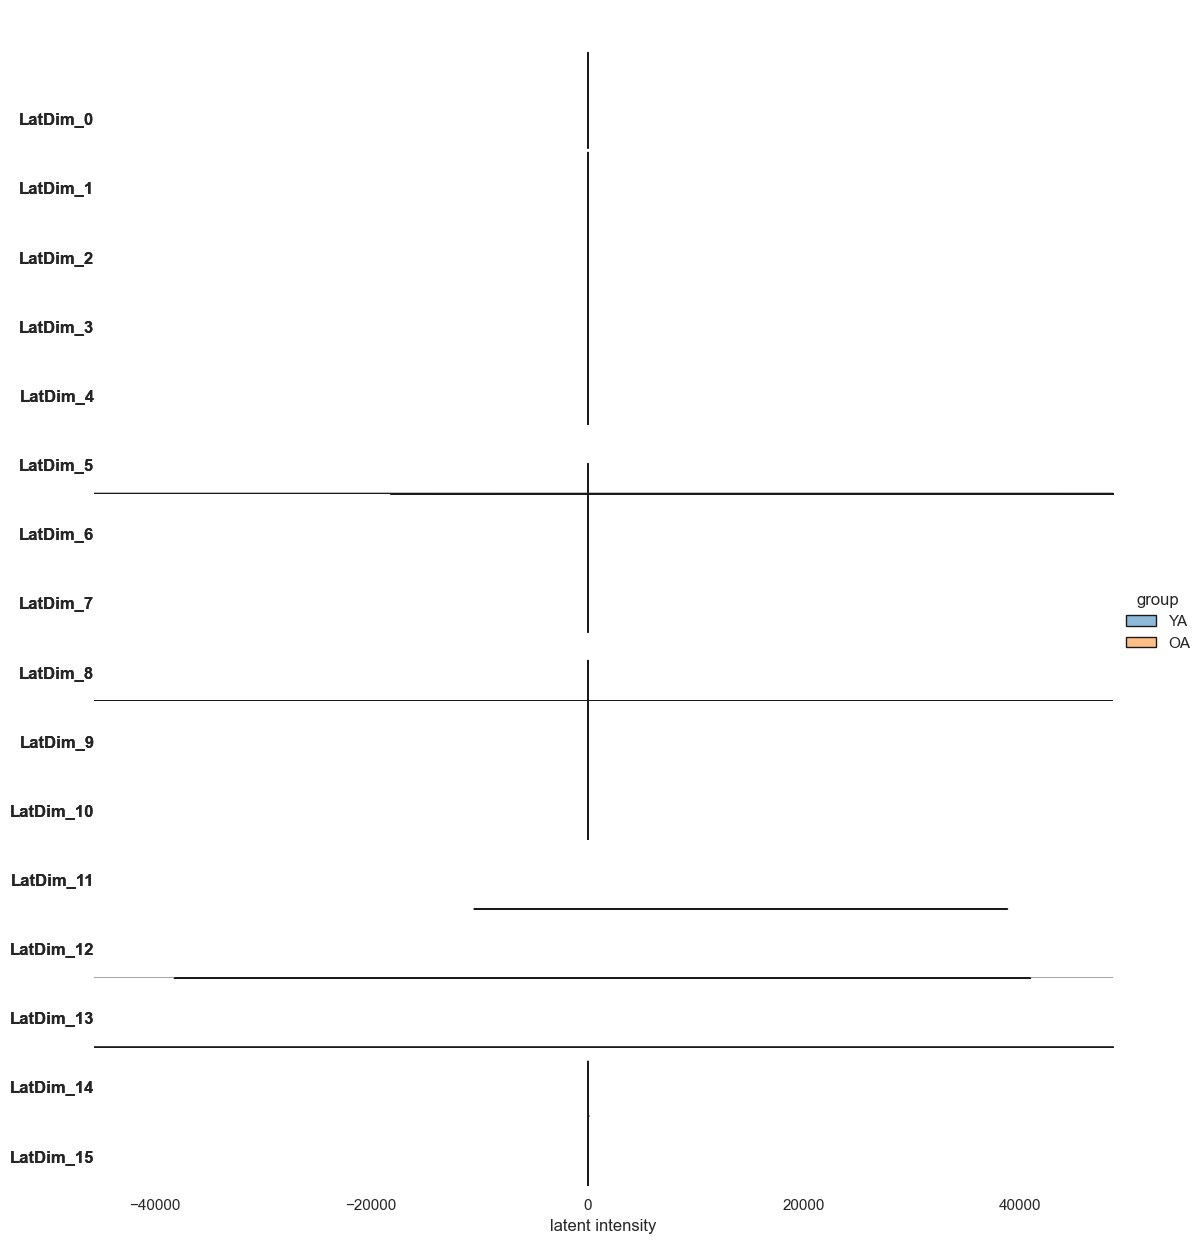

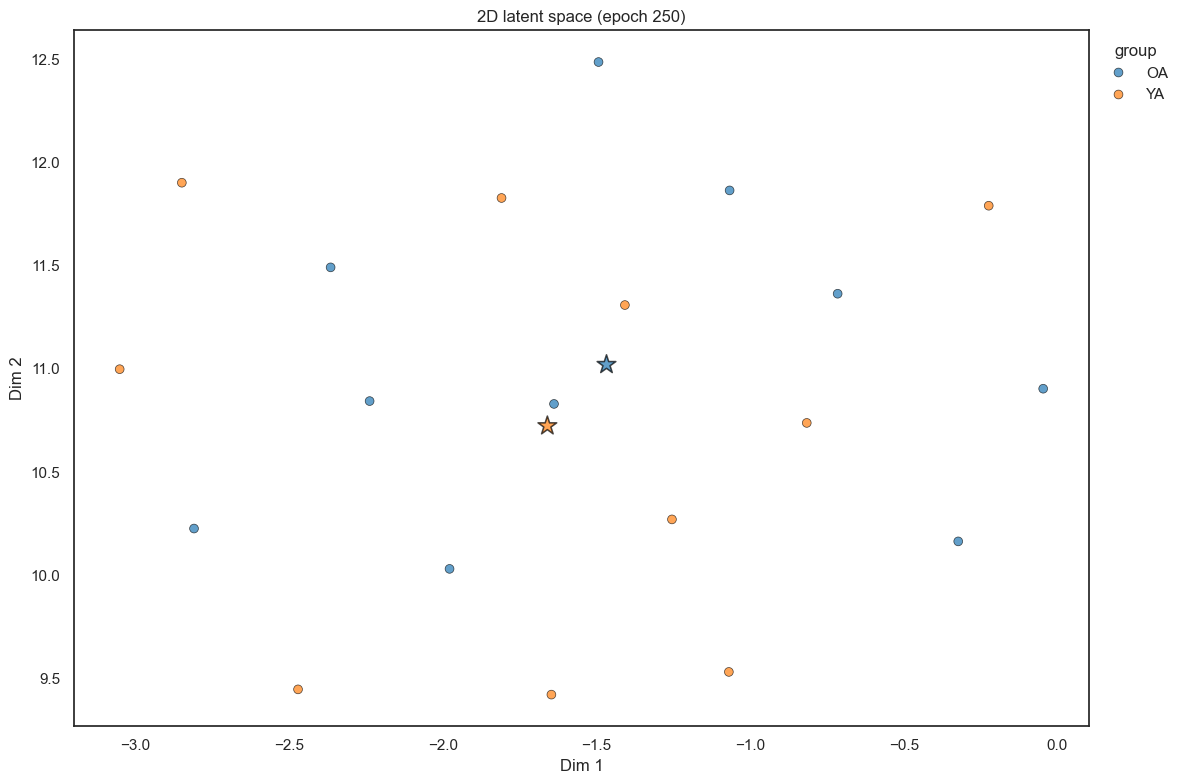

In [18]:
imagix3d.show_result(params=["group"])

## 5) Customize Imagix3D

To customize the behavior of our pipeline, you adjust the configuration.  
There are two ways to work with the config:

1. Create a customized instance of the config class.  
2. Provide a `yaml` file and use the config class to read it.  

We will focus on option 1 and show a few examples. Via the `Config` object we can apply customize the pipeline by chaning the `loss function` or the number of `epoch` or preprocessing. To get an full overview of the adjustable parameters, please refere to [2].  

In Addition, there is a way to use another architecture for the image autoencoder. We currently offer two architectures:`ImageVAEArchitecture` and `ImageVAEFastArchitecture`.
The fast architecture does not has BatchNorm and inplace activation functions, which can speed up the training process. The `ImageVAEArchitecture` is the default architecture and based on  [Yang & Uhler](https://arxiv.org/abs/1902.03515).

We can simply pass the architecture as type to the `model_type` parameter of the `Imagix` pipeline.

[2] Tutorials/DeepDives/ConfigTutorial.ipynb.

In [19]:
from autoencodix.modeling._volfast_architecture import VolumeVAEFastArchitecture
from autoencodix.modeling._volumevae_architecture import VolumeVAEArchitecture

custom_volconfig = Imagix3DConfig(
    data_case=DataCase.IMG_TO_IMG,
    img_path_col="filepath",
    spatial_shape_policy="crop_or_pad_to_shape",
    target_shape_3d=(224,224,192),
    checkpoint_interval=10,
    epochs=100,
    reconstruction_loss="mse",
    beta=0.005,
    scaling="MINMAX",
    anneal_function="logistic-late",
    data_config=DataConfig(
        data_info={
            "IMG": DataInfo(
                file_path=VOLROOT,
                scaling="MINMAX",
                data_type="IMG",
            ),
            "ANNO": DataInfo(
                file_path=VOLANNO,
                data_type="ANNOTATION",
            ),
        },
    ),
)

# to see a list of all parameters and defaults use:
custom_volconfig.print_schema()


Imagix3DConfig Configuration Parameters:
--------------------------------------------------

data_config:
  Type: <class 'autoencodix.configs.default_config.DataConfig'>
  Default: data_info={} require_common_cells=False annotation_columns=None
  Description: No description available

annotation_columns:
  Type: typing.Optional[typing.List[str]]
  Default: None
  Description: No description available

img_path_col:
  Type: <class 'str'>
  Default: img_paths
  Description: When working with images, we except a column in your annotation file that specifies the path of the image for a particular sample. Here you can define the name of this column

requires_paired:
  Type: typing.Optional[bool]
  Default: PydanticUndefined
  Description: Indicator if the samples for the xmodalix are paired, based on some sample id

data_case:
  Type: typing.Optional[autoencodix.configs.default_config.DataCase]
  Default: PydanticUndefined
  Description: Data case for the model, will be determined automati

In [20]:
imagix3d_2 = acx.Imagix3D(
    config=custom_volconfig, 
    model_type=VolumeVAEFastArchitecture
)
result = imagix3d_2.run()
backup_dataset = result.datasets

Successfully loaded 20 images for IMG
calling normalize image in _process_ing_to_img_case
anno key: IMG
Converting 14 images to torch.float32 tensors...
Converting 4 images to torch.float32 tensors...
Converting 2 images to torch.float32 tensors...
Epoch 1 - Train Loss: 390007.2857
Sub-losses: recon_loss: 390007.2857, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 384983.4375
Sub-losses: recon_loss: 384983.4375, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 389866.8929
Sub-losses: recon_loss: 389866.8929, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 2622649.5000
Sub-losses: recon_loss: 2622649.5000, var_loss: 0.0888, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Train Loss: 9149369.1429
Sub-losses: recon_loss: 9149369.1429, var_loss: 0.0737, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 3 - Valid Loss: 384680.8438
Sub

## 6) Load Save and Reuse Imagix3D

Lastly, we show how to re-use a trained pipeline, as well as how to save and load it.  
You can do the following:

- Use the trained pipeline to run the `predict` step with new data.  
- Obtain the latent space, apply transformations, and run the `decode` step of the trained pipeline.  
- Generate new data by computing  the mean and standard deviation of all encoded latent vectors in the chosen split and epoch, fitting a diagonal Gaussian to those statistics, and sampling new latent points by adding scaled Gaussian noise to that mean.
- Access the underlying PyTorch model and re-use it in any way you like.  
- Store the pipeline on disk or in the cloud, then reload it and continue using it

#### Save and Load
Best practice is to provide a file path without extension, we set the extensions internally and handle all saving and loading.

In [21]:
import zipfile
import glob
import os

basepath = "src/autoencodix/data/volumes/tutorial_res"
outpath = os.path.join(basepath, "imagix3D.pkl")
imagix3d.save(file_path=outpath)

# Saved data are stored in a .zip file
zip_path = os.path.join(basepath, "imagix3d.zip")
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZIP contents:")
    for name in zf.namelist():
        print(" -", name)

# Before loading, this file needs to be unzipped first
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(basepath)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))
print("\nPKL files:", pkl_files)
print("Model files:", model_files,"\n")

# The load functionality automatically will build the pipeline object out of the three saved files
imagix3d_loaded = acx.Imagix3D.load(outpath)

Preprocessor saved successfully.
saving memory efficient
Pipeline object saved successfully.

ZIP contents:
 - imagix3D.pkl
 - imagix3D_preprocessor.pkl
 - imagix3D_model.pth

PKL files: ['src/autoencodix/data/volumes/tutorial_res\\imagix3D.pkl', 'src/autoencodix/data/volumes/tutorial_res\\imagix3D_preprocessor.pkl']
Model files: ['src/autoencodix/data/volumes/tutorial_res\\imagix3D_model.pth'] 

Attempting to load a pipeline from src/autoencodix/data/volumes/tutorial_res\imagix3D.pkl...
Pipeline object loaded successfully. Actual type: Imagix3D
Preprocessor loaded successfully.


In [22]:
# For demonstration purposes, we use the data from step 1 again.
# In real-world scenarios, you would use different data.
result_predict = imagix3d_loaded.predict(data=backup_dataset)

Processed 4 / 4 samples

#### Decode with Latent Space Shift

In [23]:
import numpy as np
import torch

latent = imagix3d_loaded.result.latentspaces.get(split="test", epoch=-1)
latent_shift = np.random.normal(0, 0.1, latent.shape)
new_latent = (latent + latent_shift).astype(np.float32)

decoded = imagix3d_loaded.decode(torch.from_numpy(new_latent))
print(decoded.shape)

torch.Size([4, 1, 192, 224, 224])


#### Generate New Data
Because Imagix3D is variational, we can sample from a latent distribution and decode those latent vectors into new synthetic volumes.

In [24]:
generated = imagix3d_loaded.generate(n_samples=4)
print(generated.shape)

torch.Size([4, 1, 192, 224, 224])


#### Obtain PyTorch Model

In [25]:
model = result.model
# then do something with the model
print(model)

VolumeVAEFastArchitecture(
  (_encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv3d(16, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv3d(32, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv3d(128, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (mu): Linear(in_features=37632, out_features=16, bias=True)
  (logvar): Linear(in_features=37632, out_features=16, bias=True)
  (d1): Sequential(
    (0): Linear(in_features=16, out_features=376

Visualize on the new predictions.

Creating plots ...


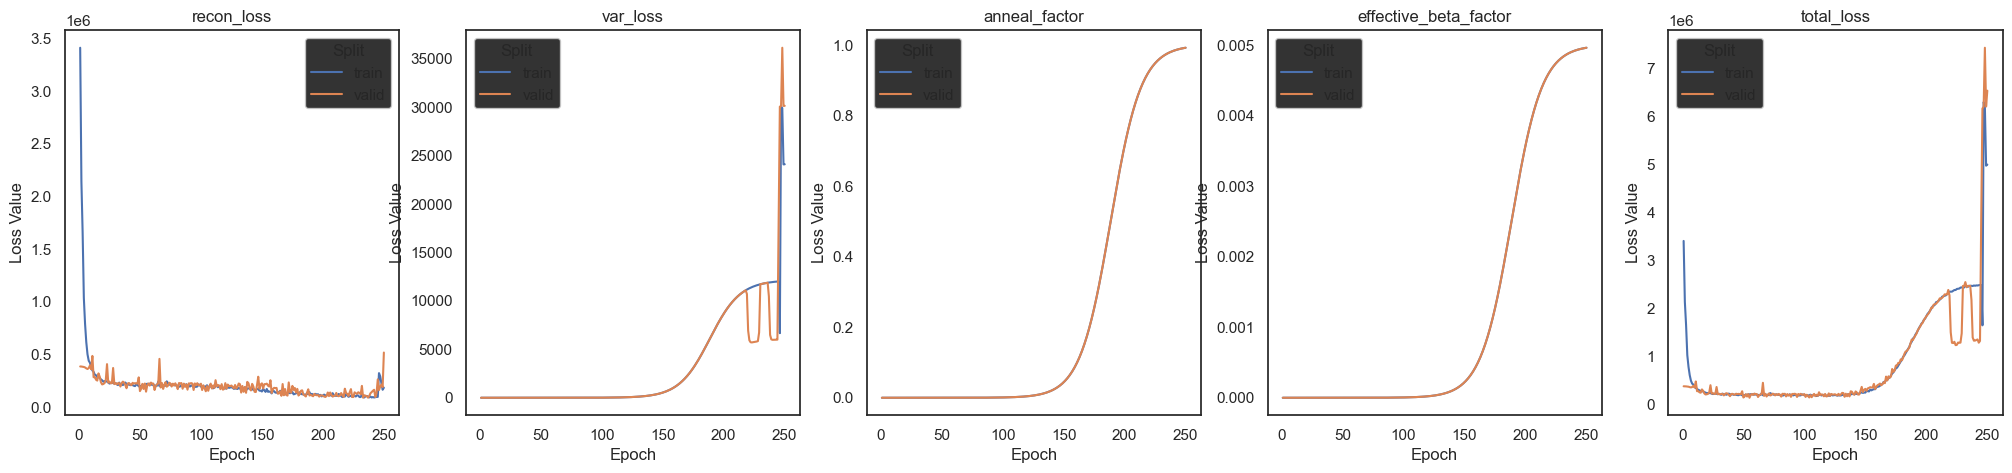

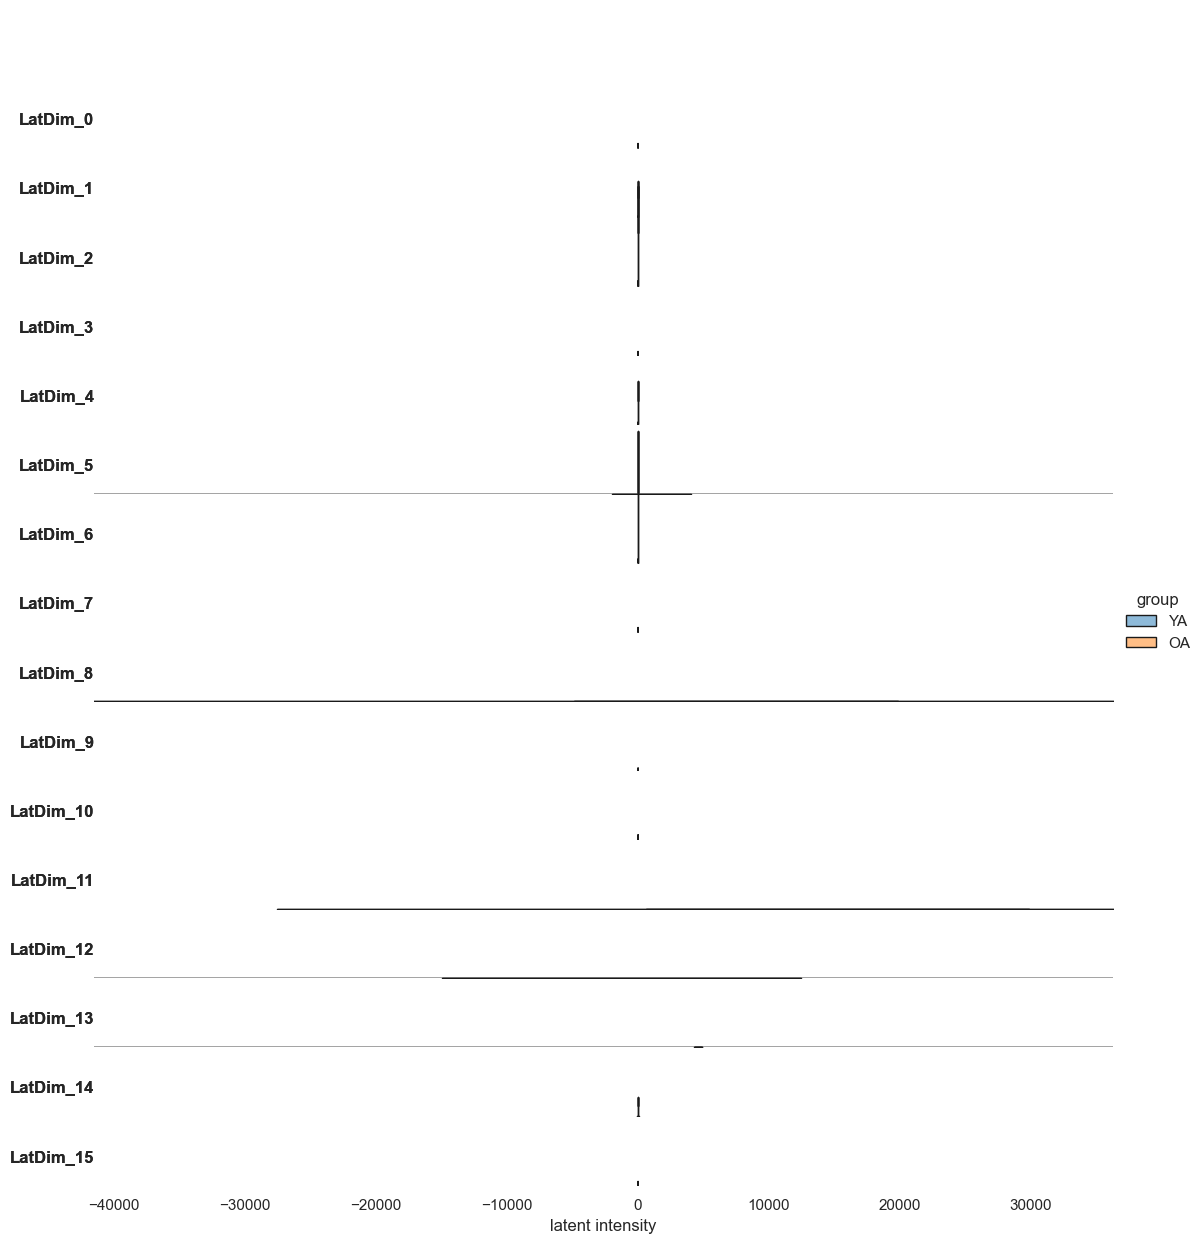

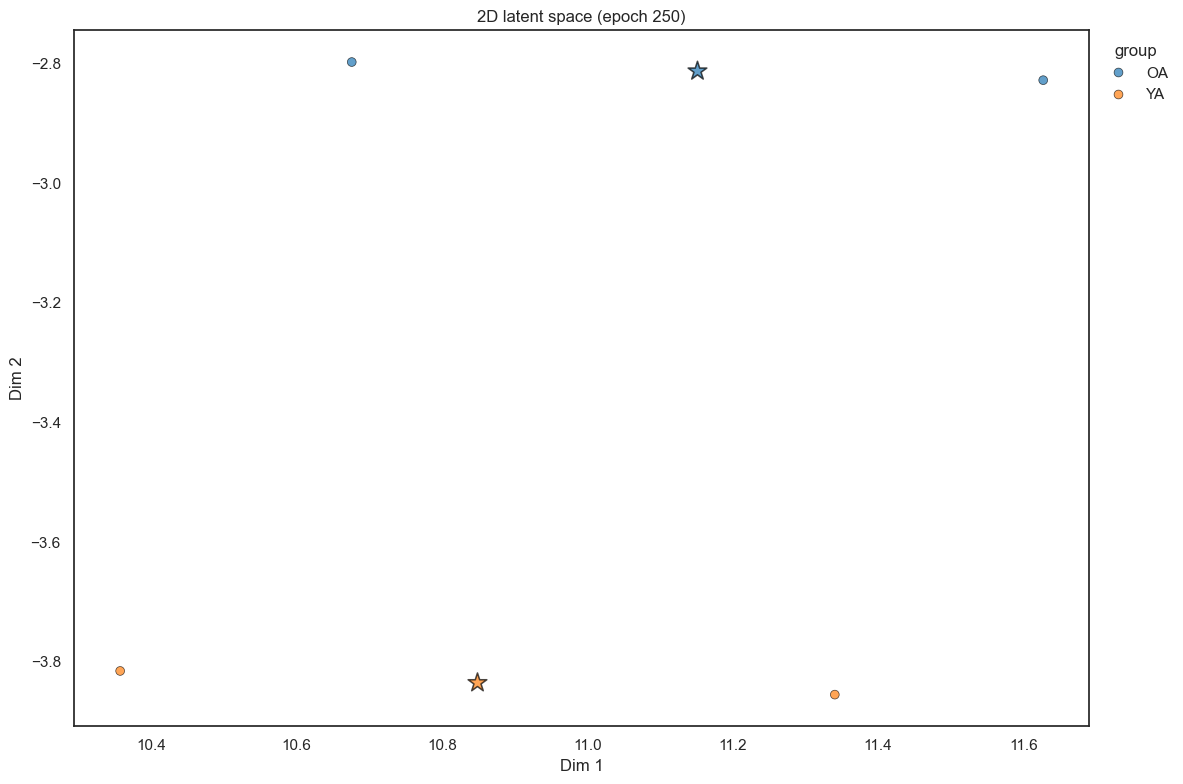

In [26]:
imagix3d_loaded.visualize()
imagix3d_loaded.show_result(params=["group"])

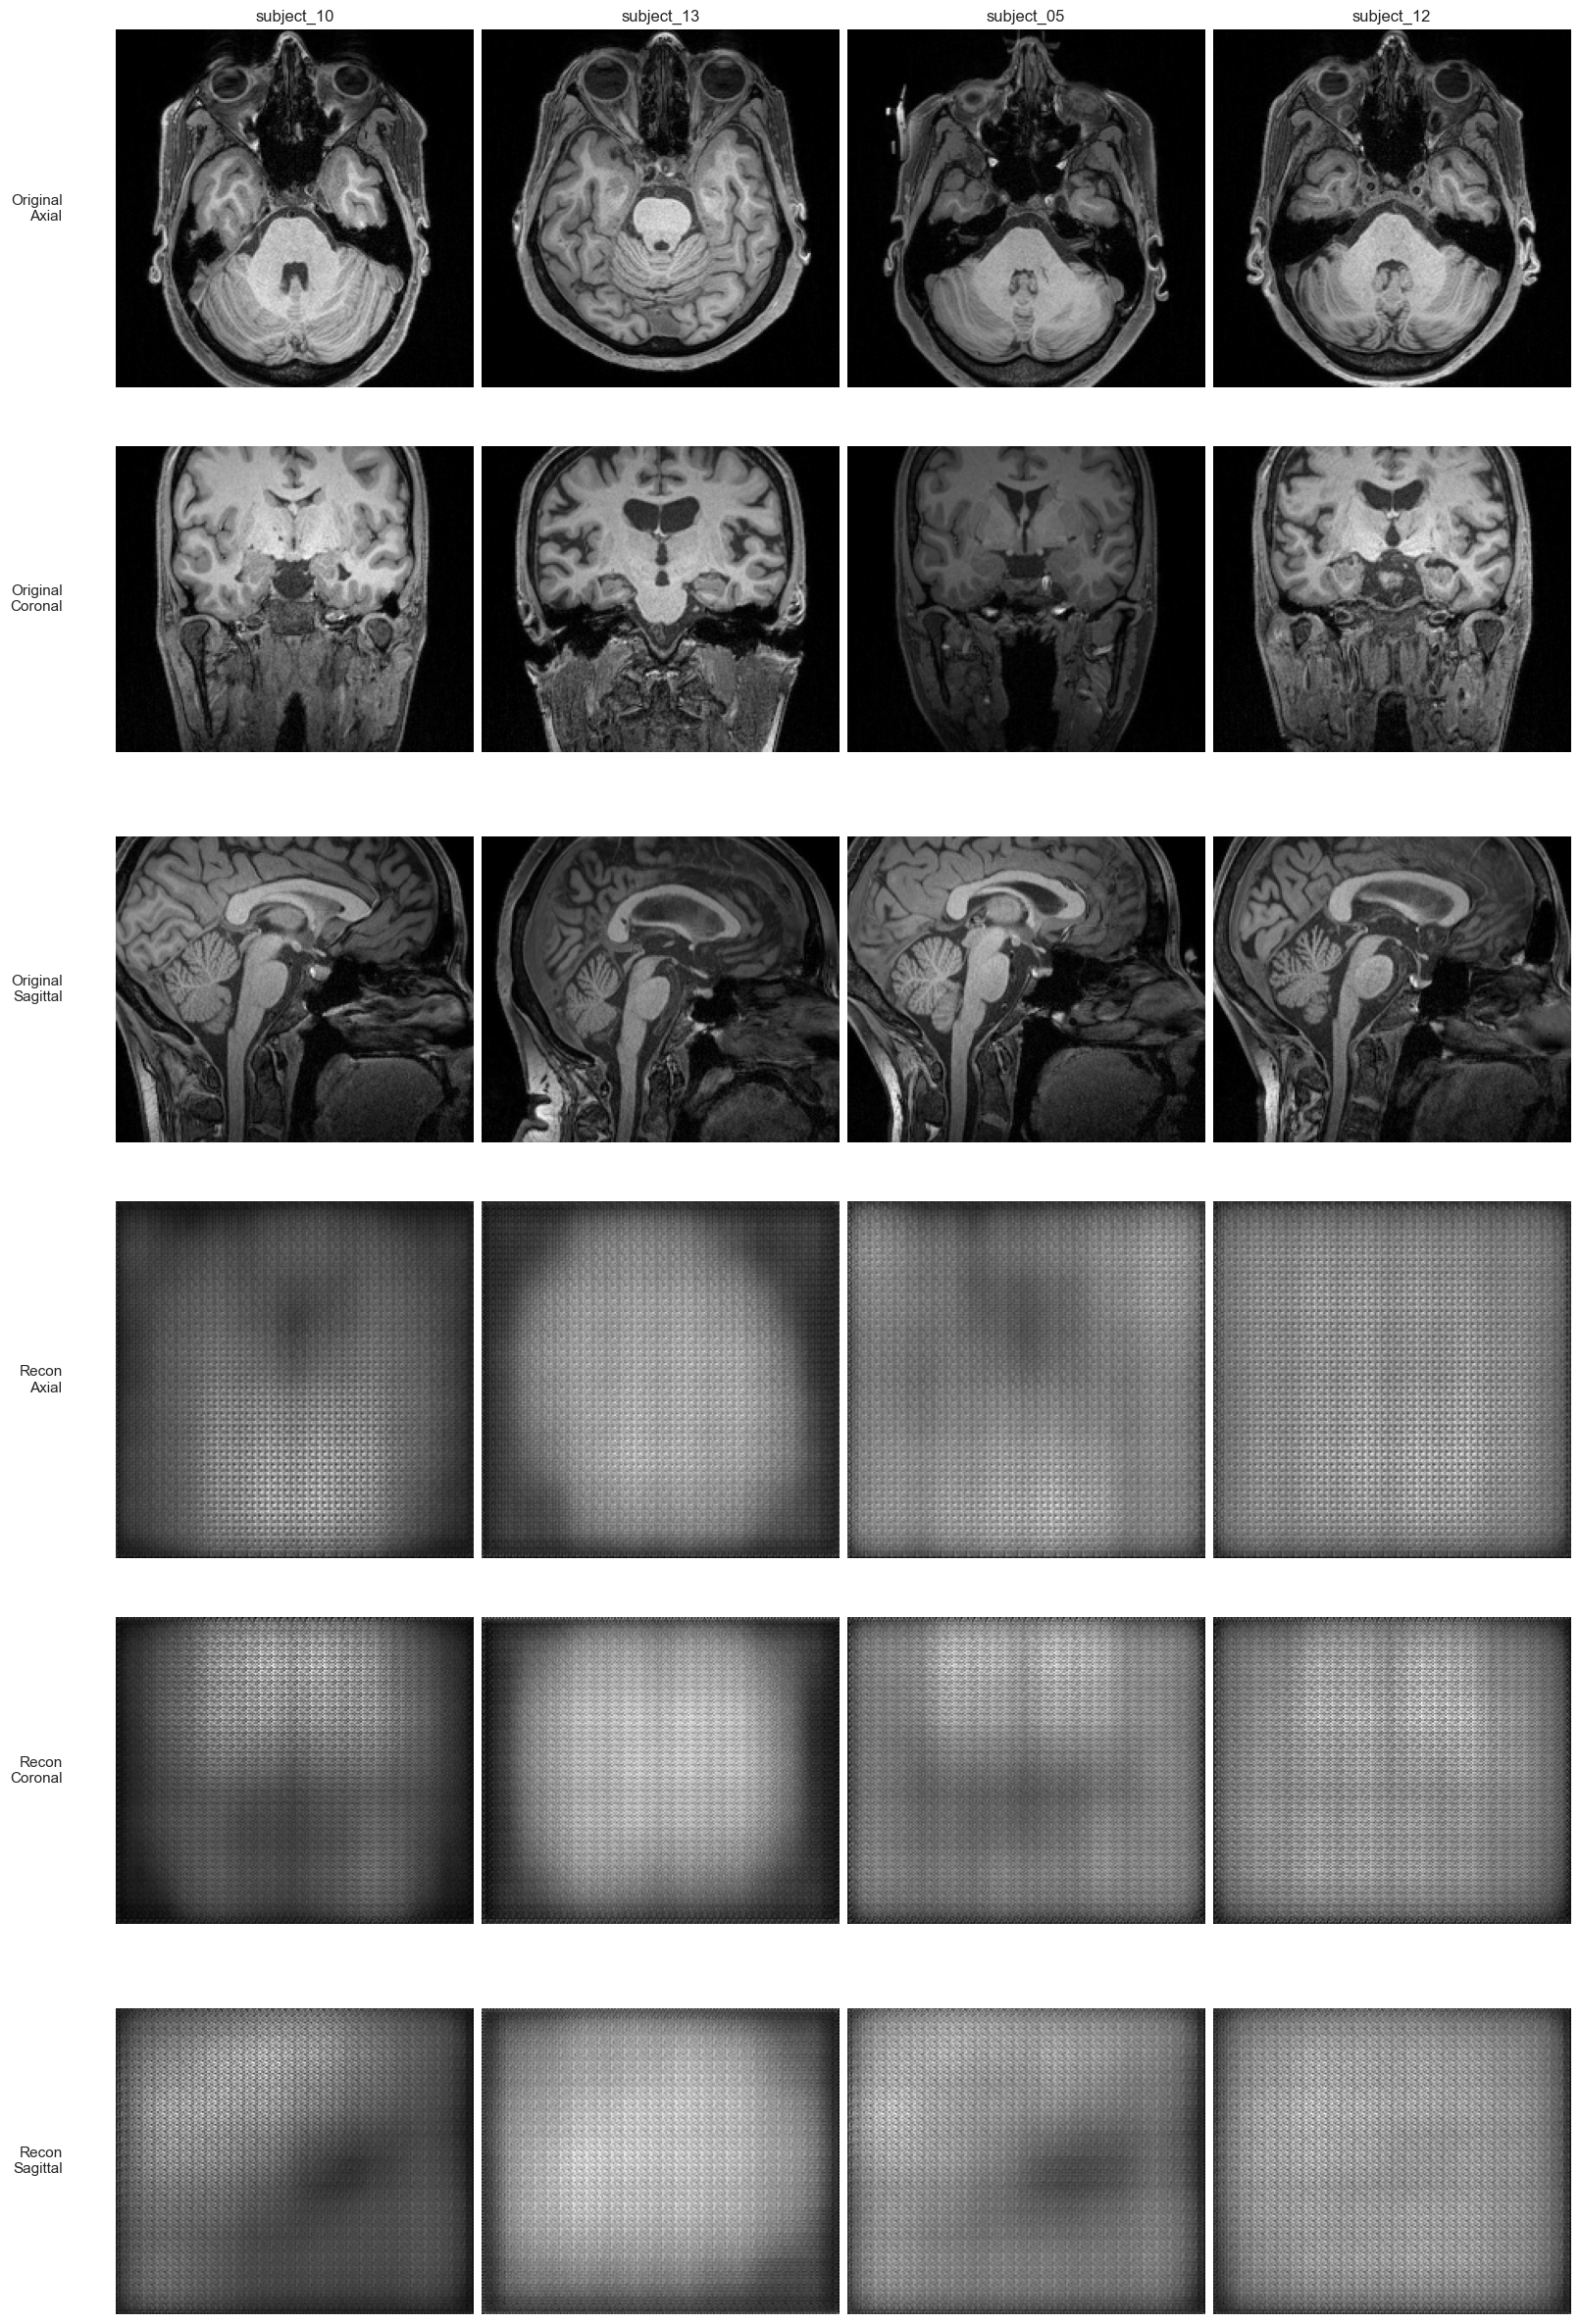

In [27]:
imagix3d_loaded.visualizer.show_image_recon_grid(result=imagix3d_loaded.result, n_samples=4)